In [1]:
# Easter Egg
import antigravity

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Mobile_Battery_Life_Prediction_Dataset.csv")

In [3]:
df.head()

,Screen_Time_Hours,Battery_Remaining_Percent
0,1.0,88.8
1,1.1,89.1
2,1.2,89.4
3,1.3,89.8
4,1.5,89.2


In [4]:
df.tail()

,Screen_Time_Hours,Battery_Remaining_Percent
75,9.5,14.0
76,9.7,13.4
77,9.8,13.8
78,9.9,14.1
79,10.0,14.4


In [5]:
# Shape
print("Shape:", df.shape)

# Information
df.info()

# Statistics
df.describe()

Shape: (80, 2)
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Screen_Time_Hours          80 non-null     float64
 1   Battery_Remaining_Percent  80 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB


,Screen_Time_Hours,Battery_Remaining_Percent
count,80.000000,80.00000
mean,5.500000,51.59500
std,2.647186,23.24474
min,1.000000,13.40000
25%,3.275000,32.40000
50%,5.500000,51.60000
75%,7.725000,70.80000
max,10.000000,89.80000


In [6]:
df.isnull().sum()

Screen_Time_Hours            0
Battery_Remaining_Percent    0
dtype: int64

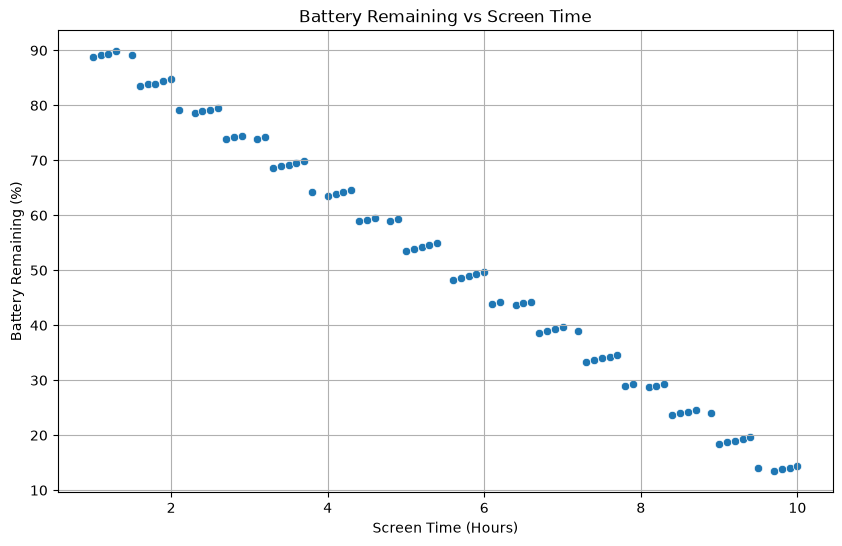

In [7]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Screen_Time_Hours',
    y='Battery_Remaining_Percent'
)

plt.title("Battery Remaining vs Screen Time")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Battery Remaining (%)")
plt.grid(True)

plt.show()

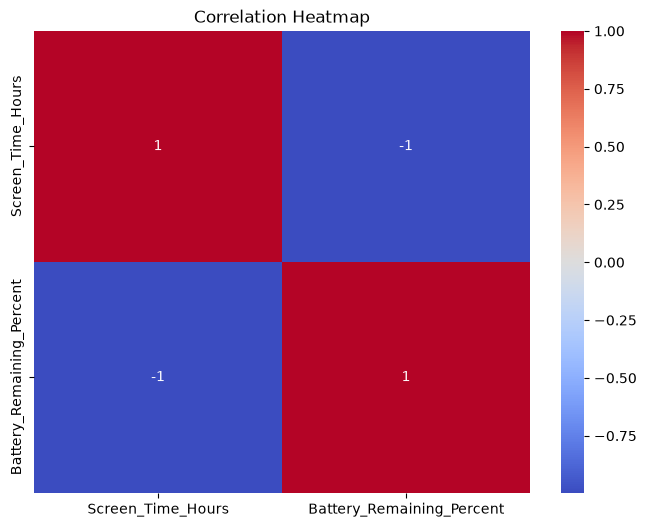

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


In [9]:
X = df[['Screen_Time_Hours']]

y = df['Battery_Remaining_Percent']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-8.76]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Screen_Time_Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,99.87
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [12]:
y_pred = model.predict(X_test)

In [13]:
print("R² Score :", r2_score(y_test, y_pred))

print("MAE :", mean_absolute_error(y_test, y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.9927648244843659
MAE : 1.588467432533773
RMSE : 1.8353481936987388


In [14]:
screen_time = float(input("Enter Screen Time (Hours): "))

prediction = model.predict([[screen_time]])

print(f"Predicted Battery Remaining: {prediction[0]:.2f}%")

Enter Screen Time (Hours):  5


Predicted Battery Remaining: 56.06%


C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


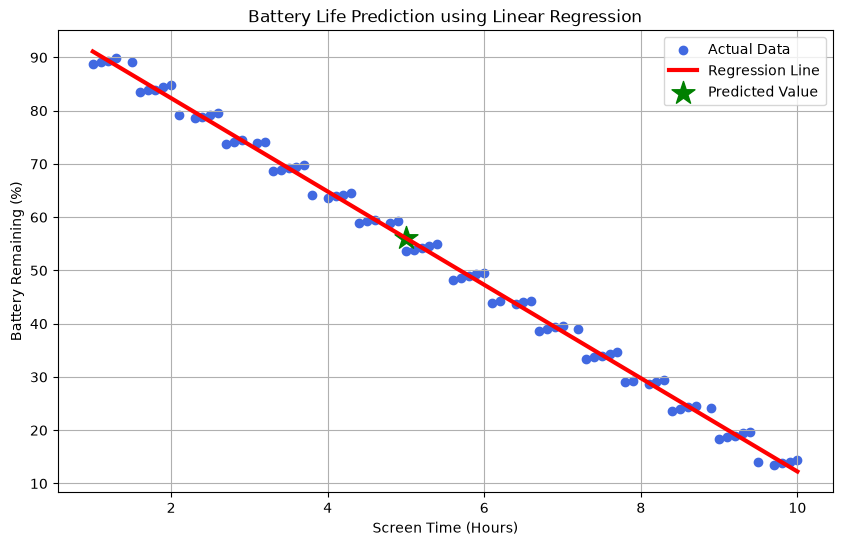

In [15]:
plt.figure(figsize=(10,6))

# Original Data
plt.scatter(
    X,
    y,
    color="royalblue",
    label="Actual Data"
)

# Regression Line
plt.plot(
    X,
    model.predict(X),
    color="red",
    linewidth=3,
    label="Regression Line"
)

# Prediction Point
plt.scatter(
    screen_time,
    prediction,
    color="green",
    marker="*",
    s=300,
    label="Predicted Value"
)

plt.xlabel("Screen Time (Hours)")
plt.ylabel("Battery Remaining (%)")
plt.title("Battery Life Prediction using Linear Regression")

plt.legend()

plt.grid(True)

plt.show()

C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


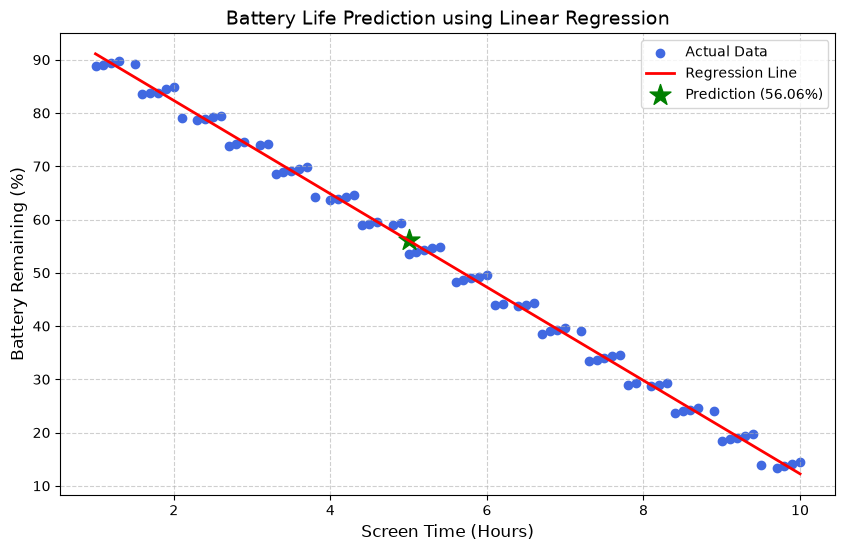

✅ Graph saved successfully in: static/regression.png


In [18]:
import os
import matplotlib.pyplot as plt

# Create the 'static' folder if it doesn't exist
os.makedirs("static", exist_ok=True)

# Make sure prediction is a single number
prediction = model.predict([[screen_time]])[0]

# Create figure
plt.figure(figsize=(10, 6))

# Plot actual data
plt.scatter(
    X["Screen_Time_Hours"],
    y,
    color="royalblue",
    label="Actual Data"
)

# Plot regression line
plt.plot(
    X["Screen_Time_Hours"],
    model.predict(X),
    color="red",
    linewidth=2,
    label="Regression Line"
)

# Plot predicted point
plt.scatter(
    screen_time,
    prediction,
    color="green",
    marker="*",
    s=250,
    label=f"Prediction ({prediction:.2f}%)"
)

# Labels and title
plt.xlabel("Screen Time (Hours)", fontsize=12)
plt.ylabel("Battery Remaining (%)", fontsize=12)
plt.title("Battery Life Prediction using Linear Regression", fontsize=14)

# Grid and legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Save graph
plt.savefig("static/regression.png", dpi=300, bbox_inches="tight")

# Show graph
plt.show()

print("✅ Graph saved successfully in: static/regression.png")

In [19]:
import joblib

joblib.dump(model, "battery_model.pkl")

print("Model saved successfully!")

Model saved successfully!
